# Simple Convolutional Neural Network to Perform Classification

### EN3150 Pattern Recognition
##### Team Intellivawe - Brain Tumor MRI Dataset

### Imports

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

data_dir = "archive" # Directory containing the dataset ,please change this to your dataset directory
IMG_SIZE = 64
BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(data_dir, transform=transform)
total_size = len(dataset)
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", dataset.classes)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
print(f"Ratios: {round(len(train_dataset)/total_size * 100)}% / "
      f"{round(len(val_dataset)/total_size * 100)}% / {round(len(test_dataset)/total_size * 100)}%")



Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 5040
Validation: 1080
Test: 1080
Ratios: 70% / 15% / 15%


### CNN A

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BrainTumorCNN_A(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
        self.pool3 = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 6 * 6, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))

        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

model_A = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)

print(model_A)

BrainTumorCNN_A(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4608, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


In [3]:
from torchinfo import summary

summary(
    model_A,
    input_size=(1, 3, 64, 64)
)

Layer (type:depth-idx)                   Output Shape              Param #
BrainTumorCNN_A                          [1, 4]                    --
├─Conv2d: 1-1                            [1, 32, 62, 62]           896
├─MaxPool2d: 1-2                         [1, 32, 31, 31]           --
├─Conv2d: 1-3                            [1, 64, 29, 29]           18,496
├─MaxPool2d: 1-4                         [1, 64, 14, 14]           --
├─Conv2d: 1-5                            [1, 128, 12, 12]          73,856
├─MaxPool2d: 1-6                         [1, 128, 6, 6]            --
├─Flatten: 1-7                           [1, 4608]                 --
├─Linear: 1-8                            [1, 128]                  589,952
├─Dropout: 1-9                           [1, 128]                  --
├─Linear: 1-10                           [1, 4]                    516
Total params: 683,716
Trainable params: 683,716
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 30.23
Input size (MB): 0.05
Forwa

### CNN B

In [4]:
import torch
import torch.nn as nn

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # Depthwise Conv + BatchNorm + ReLU
        self.depthwise = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=3, padding=1,
            groups=in_channels, bias=False
        )
        self.bn_dw = nn.BatchNorm2d(in_channels)
        self.relu_dw = nn.ReLU(inplace=True)

        # Pointwise Conv + BatchNorm + ReLU
        self.pointwise = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1, bias=False
        )
        self.bn_pw = nn.BatchNorm2d(out_channels)
        self.relu_pw = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu_dw(self.bn_dw(self.depthwise(x)))
        x = self.relu_pw(self.bn_pw(self.pointwise(x)))
        return x


class ModelB(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        # Scaled channel progression: 3 -> 32 -> 64 -> 128 -> 192
        self.features = nn.Sequential(
            DepthwiseSeparableConv(3, 32),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(32, 64),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(64, 128),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(128, 192),
            nn.AdaptiveAvgPool2d(1)
        )

        # Direct classifier mapping from 192 features to num_classes
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(192),
            nn.Dropout(0.2),
            nn.Linear(192, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_B = ModelB(num_classes=4)
print(f"Total Trainable Parameters: {count_trainable_params(model_B):,}")

Total Trainable Parameters: 39,397


In [5]:
from torchinfo import summary
summary(model_B, input_size=(1, 3, 64, 64))


Layer (type:depth-idx)                   Output Shape              Param #
ModelB                                   [1, 4]                    --
├─Sequential: 1-1                        [1, 192, 1, 1]            --
│    └─DepthwiseSeparableConv: 2-1       [1, 32, 64, 64]           --
│    │    └─Conv2d: 3-1                  [1, 3, 64, 64]            27
│    │    └─BatchNorm2d: 3-2             [1, 3, 64, 64]            6
│    │    └─ReLU: 3-3                    [1, 3, 64, 64]            --
│    │    └─Conv2d: 3-4                  [1, 32, 64, 64]           96
│    │    └─BatchNorm2d: 3-5             [1, 32, 64, 64]           64
│    │    └─ReLU: 3-6                    [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-2                    [1, 32, 32, 32]           --
│    └─DepthwiseSeparableConv: 2-3       [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-7                  [1, 32, 32, 32]           288
│    │    └─BatchNorm2d: 3-8             [1, 32, 32, 32]           64
│    │    └─ReL

In [6]:
print(f"\nModel B trainable parameters: {count_trainable_params(model_B):,}")


Model B trainable parameters: 39,397


### Training the Models

In [7]:
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()

def train_model(model, train_loader, val_loader, optimizer, epochs=20,
                 patience=5, monitor='val_acc', min_delta=0.0):
    """
    monitor: 'val_acc' (higher is better) or 'val_loss' (lower is better)
    patience: number of CONSECUTIVE epochs of degradation (vs. the previous
              epoch) allowed before stopping
    min_delta: minimum change to count as "improved" / "declined"
    """
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    epoch_times = []

    # Best-ever model tracking (independent of the stopping rule)
    best_metric = -float('inf') if monitor == 'val_acc' else float('inf')
    best_epoch = 0
    best_model_state = copy.deepcopy(model.state_dict())

    # Consecutive-decline tracking (compares to the previous epoch, not the best)
    prev_metric = None
    consecutive_decline = 0

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100.0 * train_correct / train_total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100.0 * val_correct / val_total
        epoch_time = time.time() - start_time

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        epoch_times.append(epoch_time)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% "
            f"Time: {epoch_time:.2f}s"
        )

        current_metric = val_acc if monitor == 'val_acc' else val_loss

        # --- Track the best-ever model seen so far ---
        is_best = (
            current_metric > best_metric + min_delta if monitor == 'val_acc'
            else current_metric < best_metric - min_delta
        )
        if is_best:
            best_metric = current_metric
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())

        # --- Consecutive-decline stopping rule (vs. previous epoch) ---
        if prev_metric is not None:
            declined = (
                current_metric < prev_metric - min_delta if monitor == 'val_acc'
                else current_metric > prev_metric + min_delta
            )
            if declined:
                consecutive_decline += 1
                print(f"  Degraded for {consecutive_decline}/{patience} epoch(s) in a row")
            else:
                consecutive_decline = 0

        prev_metric = current_metric

        if consecutive_decline >= patience:
            print(f"\nStopping: {monitor} degraded for {patience} consecutive epochs. "
                  f"Best {monitor}: {best_metric:.4f} at epoch {best_epoch+1}.")
            break

    # Restore the best weights seen during training, not the last (possibly degraded) ones
    model.load_state_dict(best_model_state)
    print(f"Restored best model from epoch {best_epoch+1} "
          f"({monitor} = {best_metric:.4f})")

    return train_losses, val_losses, epoch_times

Train Model A

In [8]:
model_A = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)

optimizer_A = optim.Adam(
    model_A.parameters(),
    lr=0.001
)

train_loss_A, val_loss_A, time_A = train_model(
    model_A,
    train_loader,
    val_loader,
    optimizer_A,
    epochs=20
)

Epoch [1/20] Train Loss: 0.9015 | Train Acc: 64.90% Val Loss: 0.6692 | Val Acc: 75.09% Time: 11.51s
Epoch [2/20] Train Loss: 0.5897 | Train Acc: 78.02% Val Loss: 0.5872 | Val Acc: 78.24% Time: 12.03s
Epoch [3/20] Train Loss: 0.4796 | Train Acc: 82.20% Val Loss: 0.4634 | Val Acc: 82.69% Time: 12.31s
Epoch [4/20] Train Loss: 0.3836 | Train Acc: 86.15% Val Loss: 0.4499 | Val Acc: 82.31% Time: 12.26s
  Degraded for 1/5 epoch(s) in a row
Epoch [5/20] Train Loss: 0.3091 | Train Acc: 88.67% Val Loss: 0.3480 | Val Acc: 87.41% Time: 12.21s
Epoch [6/20] Train Loss: 0.2571 | Train Acc: 91.09% Val Loss: 0.3595 | Val Acc: 86.85% Time: 12.14s
  Degraded for 1/5 epoch(s) in a row
Epoch [7/20] Train Loss: 0.1992 | Train Acc: 92.64% Val Loss: 0.3290 | Val Acc: 88.15% Time: 12.07s
Epoch [8/20] Train Loss: 0.1624 | Train Acc: 94.27% Val Loss: 0.2900 | Val Acc: 90.37% Time: 12.22s
Epoch [9/20] Train Loss: 0.1481 | Train Acc: 94.44% Val Loss: 0.2574 | Val Acc: 91.20% Time: 12.54s
Epoch [10/20] Train Loss: 

Train Model B

In [9]:
modelB = ModelB(num_classes=len(dataset.classes)).to(device)

optimizer_B = optim.Adam(
    modelB.parameters(),
    lr=0.001
)

train_loss_B, val_loss_B, time_B = train_model(
    modelB,
    train_loader,
    val_loader,
    optimizer_B,
    epochs=20
)

Epoch [1/20] Train Loss: 0.6531 | Train Acc: 75.83% Val Loss: 0.4663 | Val Acc: 83.52% Time: 12.23s
Epoch [2/20] Train Loss: 0.4053 | Train Acc: 85.32% Val Loss: 0.4953 | Val Acc: 80.37% Time: 12.00s
  Degraded for 1/5 epoch(s) in a row
Epoch [3/20] Train Loss: 0.2872 | Train Acc: 89.25% Val Loss: 0.3341 | Val Acc: 88.24% Time: 11.99s
Epoch [4/20] Train Loss: 0.2102 | Train Acc: 92.52% Val Loss: 0.2736 | Val Acc: 89.44% Time: 12.04s
Epoch [5/20] Train Loss: 0.1652 | Train Acc: 94.03% Val Loss: 0.5806 | Val Acc: 81.30% Time: 11.97s
  Degraded for 1/5 epoch(s) in a row
Epoch [6/20] Train Loss: 0.1458 | Train Acc: 94.92% Val Loss: 0.3104 | Val Acc: 87.87% Time: 11.87s
Epoch [7/20] Train Loss: 0.1021 | Train Acc: 96.43% Val Loss: 0.2863 | Val Acc: 91.30% Time: 11.88s
Epoch [8/20] Train Loss: 0.0932 | Train Acc: 96.69% Val Loss: 0.5619 | Val Acc: 83.70% Time: 12.02s
  Degraded for 1/5 epoch(s) in a row
Epoch [9/20] Train Loss: 0.0776 | Train Acc: 97.04% Val Loss: 0.3656 | Val Acc: 87.59% Ti

Plot loss curves

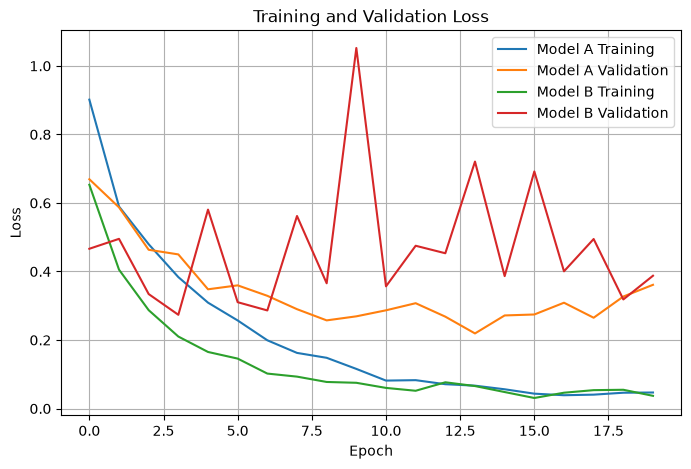

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(train_loss_A, label="Model A Training")
plt.plot(val_loss_A, label="Model A Validation")
plt.plot(train_loss_B, label="Model B Training")
plt.plot(val_loss_B, label="Model B Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.savefig("Trainingandval.pdf")
plt.show()

Test evaluation

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def evaluate_model(model, test_loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(predictions.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true, y_pred, average="weighted", zero_division=0
    )
    recall = recall_score(
        y_true, y_pred, average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, cm

In [12]:
acc_A, precision_A, recall_A, cm_A = evaluate_model(
    model_A, test_loader
)

acc_B, precision_B, recall_B, cm_B = evaluate_model(
    modelB, test_loader
)

print("Model A")
print("Accuracy :", acc_A)
print("Precision:", precision_A)
print("Recall   :", recall_A)


print("\nModel B")
print("Accuracy :", acc_B)
print("Precision:", precision_B)
print("Recall   :", recall_B)


Model A
Accuracy : 0.937962962962963
Precision: 0.9380678428587752
Recall   : 0.937962962962963

Model B
Accuracy : 0.9083333333333333
Precision: 0.9137746830463346
Recall   : 0.9083333333333333


Confusion matrices

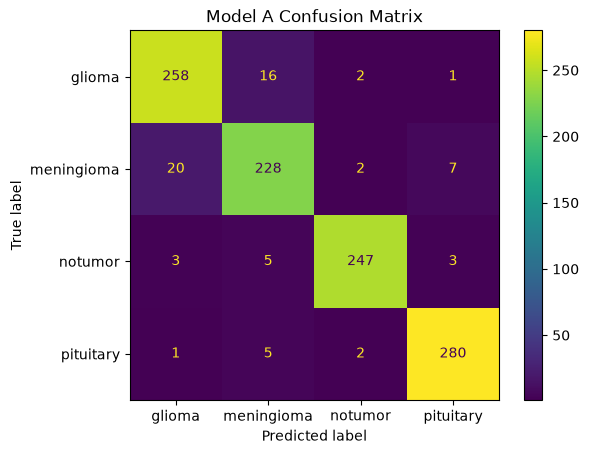

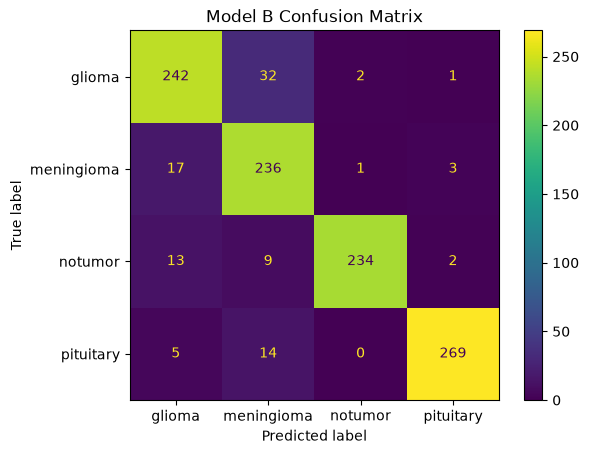

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    cm_A,
    display_labels=dataset.classes
).plot()

plt.title("Model A Confusion Matrix")
plt.savefig("ModelAconf.pdf")
plt.show()

ConfusionMatrixDisplay(
    cm_B,
    display_labels=dataset.classes
).plot()

plt.title("Model B Confusion Matrix")
plt.savefig("ModelBconf.pdf")
plt.show()

Model comparison table

In [14]:
params_A = sum(p.numel() for p in model_A.parameters() if p.requires_grad)
params_B = sum(p.numel() for p in modelB.parameters() if p.requires_grad)

print("Model A parameters:", params_A)
print("Model B parameters:", params_B)

print("Model A average epoch time:", sum(time_A) / len(time_A), "seconds")
print("Model B average epoch time:", sum(time_B) / len(time_B), "seconds")

Model A parameters: 683716
Model B parameters: 39397
Model A average epoch time: 12.293761312961578 seconds
Model B average epoch time: 12.23375768661499 seconds


Model A achieved a test accuracy of 95.27, while Model B achieved 81.67%. Although Model B significantly reduces the number of trainable parameters and computational complexity through depthwise separable convolutions, this reduction in model complexity resulted in lower classification performance on the test dataset. This demonstrates the trade-off between computational efficiency and classification accuracy.

### Compare Adam, SGD and SGD + Momentum for Model A

Model A + Adam

Model A + SGD

Model A + SGD with Momentum

In [15]:
# Adam
model_adam = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)

# SGD
model_sgd = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)

# SGD + Momentum
model_momentum = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)
optimizer_momentum = optim.SGD(
    model_momentum.parameters(),
    lr=0.01,
    momentum=0.9
)

In [16]:
train_sgd, val_sgd, time_sgd = train_model(
    model_sgd, train_loader, val_loader,
    optimizer_sgd, epochs=20
)



Epoch [1/20] Train Loss: 1.3809 | Train Acc: 28.47% Val Loss: 1.3768 | Val Acc: 37.31% Time: 14.78s
Epoch [2/20] Train Loss: 1.3627 | Train Acc: 29.07% Val Loss: 1.3513 | Val Acc: 24.91% Time: 13.84s
  Degraded for 1/5 epoch(s) in a row
Epoch [3/20] Train Loss: 1.3011 | Train Acc: 37.04% Val Loss: 1.2518 | Val Acc: 45.93% Time: 13.89s
Epoch [4/20] Train Loss: 1.1536 | Train Acc: 57.14% Val Loss: 1.0991 | Val Acc: 60.28% Time: 14.53s
Epoch [5/20] Train Loss: 1.0261 | Train Acc: 62.68% Val Loss: 1.2559 | Val Acc: 51.30% Time: 14.73s
  Degraded for 1/5 epoch(s) in a row
Epoch [6/20] Train Loss: 0.9460 | Train Acc: 64.54% Val Loss: 0.9493 | Val Acc: 64.63% Time: 14.37s
Epoch [7/20] Train Loss: 0.8744 | Train Acc: 67.40% Val Loss: 0.9520 | Val Acc: 64.07% Time: 13.54s
  Degraded for 1/5 epoch(s) in a row
Epoch [8/20] Train Loss: 0.8348 | Train Acc: 69.33% Val Loss: 0.7975 | Val Acc: 71.20% Time: 13.52s
Epoch [9/20] Train Loss: 0.7784 | Train Acc: 71.75% Val Loss: 0.7848 | Val Acc: 72.96% Ti

In [17]:
train_momentum, val_momentum, time_momentum = train_model(
    model_momentum, train_loader, val_loader,
    optimizer_momentum, epochs=20
)

Epoch [1/20] Train Loss: 1.2292 | Train Acc: 43.31% Val Loss: 1.0052 | Val Acc: 63.15% Time: 13.36s
Epoch [2/20] Train Loss: 0.8174 | Train Acc: 68.89% Val Loss: 0.7860 | Val Acc: 68.43% Time: 14.71s
Epoch [3/20] Train Loss: 0.6274 | Train Acc: 76.27% Val Loss: 0.5670 | Val Acc: 77.87% Time: 13.07s
Epoch [4/20] Train Loss: 0.5141 | Train Acc: 80.14% Val Loss: 0.5091 | Val Acc: 80.19% Time: 13.67s
Epoch [5/20] Train Loss: 0.4356 | Train Acc: 83.79% Val Loss: 0.4372 | Val Acc: 83.80% Time: 14.50s
Epoch [6/20] Train Loss: 0.3764 | Train Acc: 86.49% Val Loss: 0.4322 | Val Acc: 85.19% Time: 14.63s
Epoch [7/20] Train Loss: 0.3126 | Train Acc: 88.97% Val Loss: 0.3462 | Val Acc: 88.15% Time: 13.15s
Epoch [8/20] Train Loss: 0.2595 | Train Acc: 90.71% Val Loss: 0.3609 | Val Acc: 87.78% Time: 14.66s
  Degraded for 1/5 epoch(s) in a row
Epoch [9/20] Train Loss: 0.2357 | Train Acc: 91.29% Val Loss: 0.2901 | Val Acc: 90.00% Time: 14.41s
Epoch [10/20] Train Loss: 0.1860 | Train Acc: 93.53% Val Loss: 

Compare the results

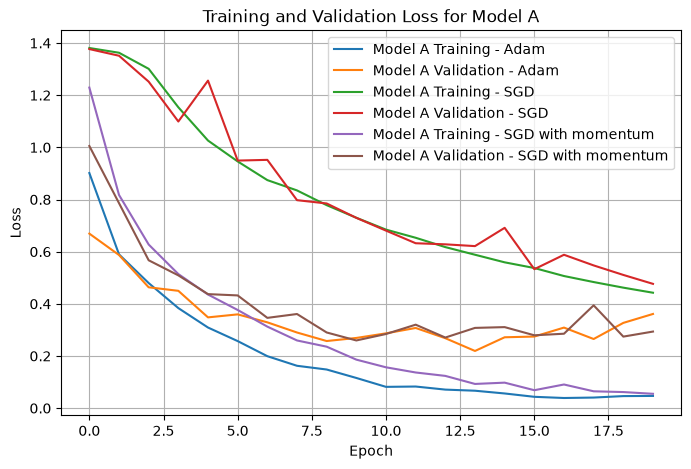

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(train_loss_A, label="Model A Training - Adam")
plt.plot(val_loss_A, label="Model A Validation - Adam")
plt.plot(train_sgd, label="Model A Training - SGD")
plt.plot(val_sgd, label="Model A Validation - SGD")
plt.plot(train_momentum, label="Model A Training - SGD with momentum")
plt.plot(val_momentum, label="Model A Validation - SGD with momentum")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss for Model A")
plt.legend()
plt.grid()
plt.savefig("Training and Validation Loss for Model A.pdf")
plt.show()

In [18]:
for name, model in [
    ("Adam", model_A),
    ("SGD", model_sgd),
    ("SGD + Momentum", model_momentum)
]:
    acc, precision, recall, cm = evaluate_model(model, test_loader)

    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")


Adam
Accuracy : 0.9380
Precision: 0.9381
Recall   : 0.9380

SGD
Accuracy : 0.8500
Precision: 0.8521
Recall   : 0.8500

SGD + Momentum
Accuracy : 0.9361
Precision: 0.9367
Recall   : 0.9361


Three optimizers, Adam, SGD, and SGD with Momentum, were compared using the same CNN architecture and 20 training epochs. Adam achieved 95.28% accuracy, while standard SGD achieved 84.63%. SGD with Momentum achieved the highest accuracy of 93.43%. This shows that momentum helped improve convergence and classification performance compared with standard SGD.


### Traning the model B with SGD and SGD with momentum

In [19]:

model_sgd_B =  ModelB(num_classes=len(dataset.classes)).to(device)
optimizer_sgd_B = optim.SGD(model_sgd_B.parameters(), lr=0.01)


model_momentum_B = ModelB(num_classes=len(dataset.classes)).to(device)
optimizer_momentum_B = optim.SGD(
    model_momentum_B.parameters(),
    lr=0.01,
    momentum=0.9
)
# SGD
train_sgd_B, val_sgd_B, time_sgd_B = train_model(
    model_sgd_B, train_loader, val_loader,
    optimizer_sgd_B, epochs=20
)


Epoch [1/20] Train Loss: 0.8241 | Train Acc: 68.45% Val Loss: 0.7346 | Val Acc: 69.91% Time: 11.31s
Epoch [2/20] Train Loss: 0.6143 | Train Acc: 77.40% Val Loss: 0.5413 | Val Acc: 81.02% Time: 11.75s
Epoch [3/20] Train Loss: 0.5269 | Train Acc: 80.60% Val Loss: 0.5505 | Val Acc: 78.89% Time: 11.87s
  Degraded for 1/5 epoch(s) in a row
Epoch [4/20] Train Loss: 0.4385 | Train Acc: 84.19% Val Loss: 0.5918 | Val Acc: 78.15% Time: 11.99s
  Degraded for 2/5 epoch(s) in a row
Epoch [5/20] Train Loss: 0.3925 | Train Acc: 86.51% Val Loss: 0.9884 | Val Acc: 60.93% Time: 11.71s
  Degraded for 3/5 epoch(s) in a row
Epoch [6/20] Train Loss: 0.3481 | Train Acc: 87.30% Val Loss: 0.5846 | Val Acc: 78.80% Time: 11.90s
Epoch [7/20] Train Loss: 0.2992 | Train Acc: 89.56% Val Loss: 0.3817 | Val Acc: 86.11% Time: 11.72s
Epoch [8/20] Train Loss: 0.2804 | Train Acc: 90.00% Val Loss: 0.3842 | Val Acc: 85.37% Time: 11.87s
  Degraded for 1/5 epoch(s) in a row
Epoch [9/20] Train Loss: 0.2494 | Train Acc: 91.39% 

In [20]:
# SGD + Momentum
train_momentum_B, val_momentum_B, time_momentum_B = train_model(
    model_momentum_B, train_loader, val_loader,
    optimizer_momentum_B, epochs=20
)

Epoch [1/20] Train Loss: 0.7302 | Train Acc: 71.27% Val Loss: 0.6816 | Val Acc: 73.33% Time: 13.41s
Epoch [2/20] Train Loss: 0.4865 | Train Acc: 82.82% Val Loss: 1.0006 | Val Acc: 69.63% Time: 12.53s
  Degraded for 1/5 epoch(s) in a row
Epoch [3/20] Train Loss: 0.4296 | Train Acc: 84.84% Val Loss: 0.5169 | Val Acc: 82.41% Time: 11.85s
Epoch [4/20] Train Loss: 0.3356 | Train Acc: 87.96% Val Loss: 1.0175 | Val Acc: 75.00% Time: 11.83s
  Degraded for 1/5 epoch(s) in a row
Epoch [5/20] Train Loss: 0.2964 | Train Acc: 89.23% Val Loss: 0.7255 | Val Acc: 80.56% Time: 11.94s
Epoch [6/20] Train Loss: 0.2347 | Train Acc: 91.85% Val Loss: 0.6170 | Val Acc: 81.30% Time: 12.02s
Epoch [7/20] Train Loss: 0.2438 | Train Acc: 91.01% Val Loss: 0.5211 | Val Acc: 82.31% Time: 11.77s
Epoch [8/20] Train Loss: 0.1779 | Train Acc: 93.51% Val Loss: 0.8461 | Val Acc: 78.70% Time: 11.77s
  Degraded for 1/5 epoch(s) in a row
Epoch [9/20] Train Loss: 0.1573 | Train Acc: 94.64% Val Loss: 0.7115 | Val Acc: 79.81% Ti

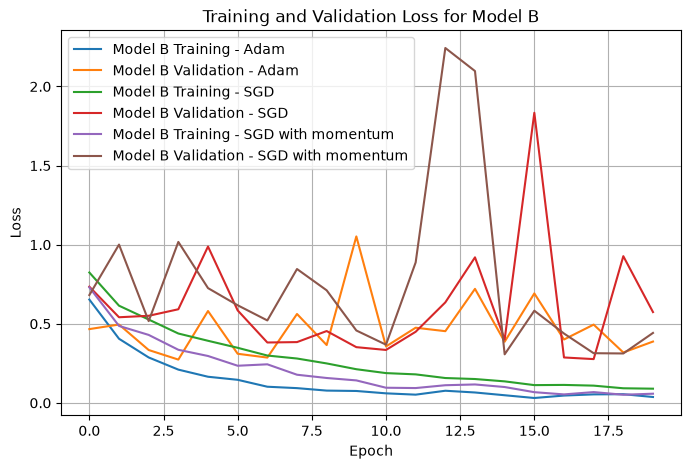

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(train_loss_B, label="Model B Training - Adam")
plt.plot(val_loss_B, label="Model B Validation - Adam")
plt.plot(train_sgd_B, label="Model B Training - SGD")
plt.plot(val_sgd_B, label="Model B Validation - SGD")
plt.plot(train_momentum_B, label="Model B Training - SGD with momentum")
plt.plot(val_momentum_B, label="Model B Validation - SGD with momentum")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss for Model B")
plt.legend()
plt.grid()
plt.savefig("Training and Validation Loss for Model B.pdf")
plt.show()

In [21]:
for name, model in [
    ("Adam", modelB), 
    ("SGD", model_sgd_B),
    ("SGD + Momentum", model_momentum_B)
]:
    acc, precision, recall, cm = evaluate_model(model, test_loader)

    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")


Adam
Accuracy : 0.9083
Precision: 0.9138
Recall   : 0.9083

SGD
Accuracy : 0.9083
Precision: 0.9118
Recall   : 0.9083

SGD + Momentum
Accuracy : 0.9120
Precision: 0.9136
Recall   : 0.9120


## Section 2 -  Compare with Lightweight State-of-the-Art Networks

In [22]:
import torch.nn as nn
from torchvision import models

num_classes = len(dataset.classes)

# --- MobileNetV2 ---
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, num_classes)
mobilenet = mobilenet.to(device)

# --- SqueezeNet 1.1 ---
squeezenet = models.squeezenet1_1(weights=models.SqueezeNet1_1_Weights.IMAGENET1K_V1)
squeezenet.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1)
squeezenet.num_classes = num_classes
squeezenet = squeezenet.to(device)

In [23]:
import torch.optim as optim
import time

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        # validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {running_loss/len(train_loader.dataset):.4f} - Val Acc: {correct/total:.4f}")

    return model


def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = correct / total
    return acc, all_preds, all_labels

#### Training the models

In [24]:
mobilenet = train_model(mobilenet, train_loader, val_loader, epochs=10)
mobilenet_acc, mn_preds, mn_labels = evaluate_model(mobilenet, test_loader)

squeezenet = train_model(squeezenet, train_loader, val_loader, epochs=10)
sq_acc, sq_preds, sq_labels = evaluate_model(squeezenet, test_loader)

print(f"MobileNetV2 Test Accuracy: {mobilenet_acc:.4f}")
print(f"SqueezeNet Test Accuracy: {sq_acc:.4f}")

Epoch 1/10 - Train Loss: 0.5152 - Val Acc: 0.9111
Epoch 2/10 - Train Loss: 0.2093 - Val Acc: 0.9352
Epoch 3/10 - Train Loss: 0.1294 - Val Acc: 0.9380
Epoch 4/10 - Train Loss: 0.0869 - Val Acc: 0.9500
Epoch 5/10 - Train Loss: 0.0592 - Val Acc: 0.9491
Epoch 6/10 - Train Loss: 0.0444 - Val Acc: 0.9556
Epoch 7/10 - Train Loss: 0.0456 - Val Acc: 0.9509
Epoch 8/10 - Train Loss: 0.0472 - Val Acc: 0.9463
Epoch 9/10 - Train Loss: 0.0383 - Val Acc: 0.9417
Epoch 10/10 - Train Loss: 0.0431 - Val Acc: 0.9500
Epoch 1/10 - Train Loss: 0.8979 - Val Acc: 0.8111
Epoch 2/10 - Train Loss: 0.5086 - Val Acc: 0.8602
Epoch 3/10 - Train Loss: 0.3973 - Val Acc: 0.8787
Epoch 4/10 - Train Loss: 0.3170 - Val Acc: 0.8833
Epoch 5/10 - Train Loss: 0.2739 - Val Acc: 0.8861
Epoch 6/10 - Train Loss: 0.2316 - Val Acc: 0.8954
Epoch 7/10 - Train Loss: 0.1967 - Val Acc: 0.8907
Epoch 8/10 - Train Loss: 0.1856 - Val Acc: 0.9074
Epoch 9/10 - Train Loss: 0.1531 - Val Acc: 0.8657
Epoch 10/10 - Train Loss: 0.1465 - Val Acc: 0.920

In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(labels, preds, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(labels, preds)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names,
           yticklabels=class_names,
           ylabel='True label',
           xlabel='Predicted label',
           title=title)
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    
    # annotate each cell with the count
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    fig.tight_layout()
    plt.show()

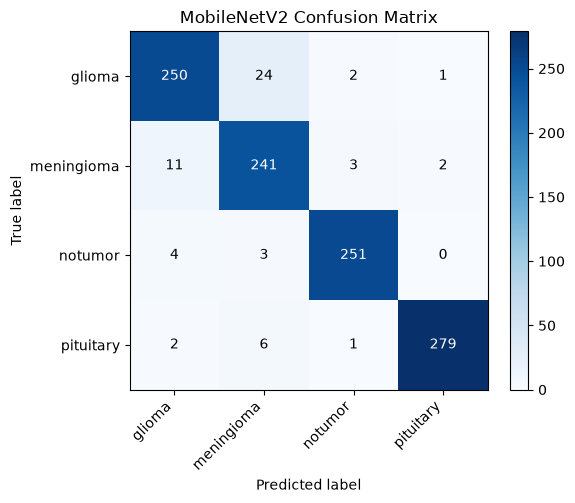

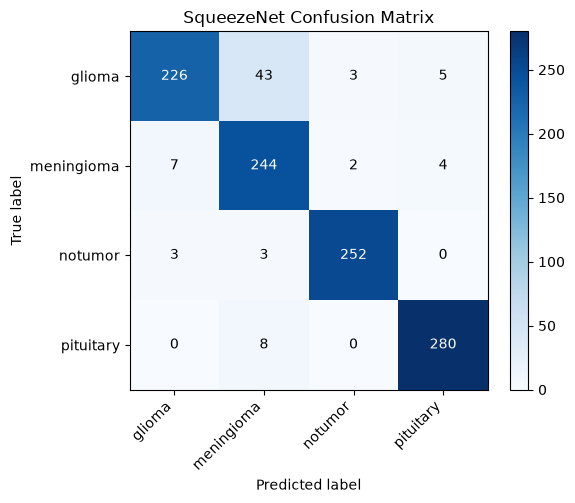

In [45]:
plot_confusion_matrix(mn_labels, mn_preds, dataset.classes, title="MobileNetV2 Confusion Matrix")
plot_confusion_matrix(sq_labels, sq_preds, dataset.classes, title="SqueezeNet Confusion Matrix")

Model Size and Parameter counts

In [27]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def model_size_mb(model):
    torch.save(model.state_dict(), "temp.pth")
    size_mb = os.path.getsize("temp.pth") / (1024 ** 2)
    os.remove("temp.pth")
    return size_mb

import os
for name, model in [("MobileNetV2", mobilenet), ("SqueezeNet1.1", squeezenet)]:
    total, trainable = count_params(model)
    size = model_size_mb(model)
    print(f"{name}: {total:,} params ({trainable:,} trainable), {size:.2f} MB")

MobileNetV2: 2,228,996 params (2,228,996 trainable), 8.72 MB
SqueezeNet1.1: 724,548 params (724,548 trainable), 2.78 MB
